In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process

from tqdm.auto import tqdm
import multiprocessing as mp


# Estimate effect size via bootstrapping thresholds

Done in `human_loc_power_analysis.py`

In [2]:
import re 
### Load in bootstrap runs:
bootstrap_results = list(Path('human_loc_power_analysis_v2').glob("*.npy"))
print(len(bootstrap_results))
n_samp_splits = {ix:[] for ix in range(3,10)} # 7 max - 2 min 
for file in bootstrap_results:
    if 'subset' not in file.stem:
        continue
    sample_size = int(re.search(r'sample_size_(\d+)_subset', file.stem).group(1))
    # else:
        # sample_size = int(re.search(r'sizes_(\d+)', file.stem).group(1))
    # use re to get integer index from file path in pattern: "sample_size_{ix}_subset"
    # results array is 2d array with shape (n_sample_size_boots, (mean, CI size, upper ci, lower ci))
    bootstrap_results_array = np.load(file).squeeze()
    if bootstrap_results_array.ndim != 2:
        print(file)
        continue
    if len(n_samp_splits[sample_size]) == 0:
        n_samp_splits[sample_size] = bootstrap_results_array
    else:
        n_samp_splits[sample_size] = np.vstack([n_samp_splits[sample_size], bootstrap_results_array])



700


[3, 4, 5, 6, 7, 8, 9]


Text(0.5, 1.0, 'Power as function of\nSNR difference and sample size')

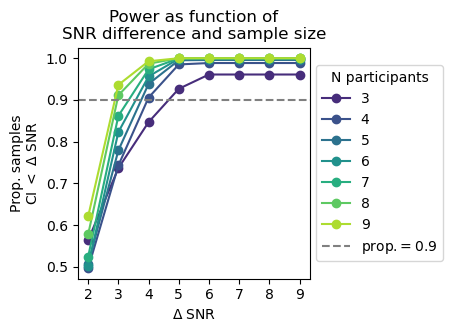

In [3]:
### Compute proporition of times given detectability is within a given snr

# for a given SNR (e.g. 2dB), plot the proportion of bootstrapped samples that had confidence intervals widths less than or equal that SNR
# ploting this quantity as a function of sample size shows the likelihood of detecting a given dB SNR difference in thresholds for that sample size

# for each sample size, compute the proportion of times the difference in the confidence interval is greater than the SNR threshold 
plt.figure(figsize=(3, 3))

# pick four colors 

min_thresholds = list(np.arange(2,10)) # dB 
samp_sizes = list(n_samp_splits.keys())
print(samp_sizes)
colors = sns.color_palette('viridis', len(samp_sizes))

for sample_size, bootstrap_results_array in n_samp_splits.items():
    if sample_size == 2:
        continue

    props = []
    for min_thresh in min_thresholds:   
        props.append(np.mean(bootstrap_results_array[:,1] < min_thresh))

    plt.plot(min_thresholds, props,  'o-', color=colors[samp_sizes.index(sample_size)], label=f"{sample_size}")

    
plt.xlabel("$\Delta$ SNR")
plt.ylabel("Prop. samples\nCI $<$ $\Delta$ SNR")
# set x ticks to match sample sizes 
plt.xticks(min_thresholds);
plt.axhline(0.9, color='grey', linestyle='--', label='prop.$=0.9$')
plt.legend(title='N participants', bbox_to_anchor=(1.6, 0.5), loc='center right')
# add legend and move to right side of figure 

# plot y line at 0.9

plt.title(f"Power as function of\nSNR difference and sample size")





[3, 4, 5, 6, 7, 8, 9]


(0.0, 7.0)

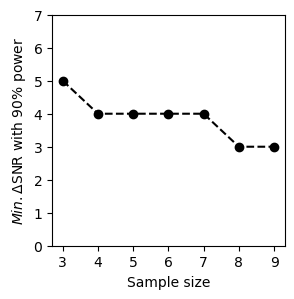

In [4]:
### Compute proporition of times given detectability is within a given snr

# for a given SNR (e.g. 2dB) this is the proportion of trials where the difference in returned confidence intervals is less than or equal to that the SNR
# this means the error in the estimate is small enough to allow for a difference of this magnitude to be reliably measured.  


# for each sample size, compute the proportion of times the difference in the confidence interval is greater than the SNR threshold 
plt.figure(figsize=(3, 3))

# pick four colors 

min_thresholds = np.arange(2,10) # dB 
samp_sizes = list(n_samp_splits.keys())
print(samp_sizes)
colors = sns.color_palette('viridis', len(samp_sizes))
power_level = 0.9 # 90% power 

props = []
for sample_size, bootstrap_results_array in n_samp_splits.items():
    if sample_size == 2:
        continue
    # if len(bootstrap_results_array) == 0:
    #     continue
    # props = []
    # n_good_samp_sizes = 0
    # find min threshold where 90% of samples are below that threshold
    snr_ix = np.where(np.mean(bootstrap_results_array[:,1] < min_thresholds.reshape(-1,1), axis=1) > power_level)[0].min()
    min_thresh = min_thresholds[snr_ix]
    props.append(min_thresh)

    # for min_thresh in min_thresholds:   
        # props.append(np.mean(bootstrap_results_array[:,1] < min_thresh))

plt.plot(samp_sizes, props,  'o--', color='k', label=f"{sample_size}")

    
plt.xlabel("Sample size")
plt.ylabel(f"$Min. \Delta$SNR with {power_level:.0%} power")
# set x ticks to match sample sizes 
plt.xticks(samp_sizes);
plt.ylim(0,7)
# plt.axhline(0.9, color='grey', linestyle='--', label='prop.$=0.9$')
# plt.legend(title='N participants', bbox_to_anchor=(1.6, 0.5), loc='center right')
# add legend and move to right side of figure 

# plot y line at 0.9

# plt.title(f"Power as function of\nSNR difference and sample size", y=1.05)





[3, 4, 5, 6, 7, 8, 9]


Text(0.5, 1.0, 'Power as function of\nSNR difference and sample size')

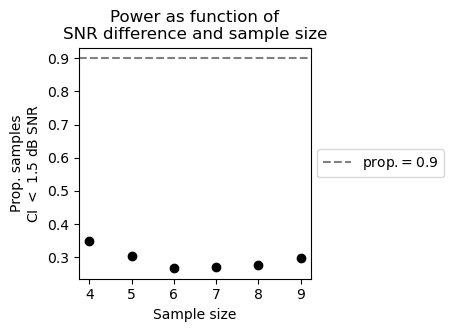

In [8]:

# for each sample size, compute the proportion of times the difference in the confidence interval is greater than the SNR threshold 
plt.figure(figsize=(3, 3))

# pick four colors 

effect_size = 1.5 # dB 
samp_sizes = list(n_samp_splits.keys())
print(samp_sizes)
colors = sns.color_palette('viridis', len(samp_sizes))

for sample_size, bootstrap_results_array in n_samp_splits.items():
    if sample_size < 4:
        continue
    prop = np.mean(bootstrap_results_array[:,1] < effect_size)

    # plt.plot(min_thresholds, props,  'o-', color=colors[samp_sizes.index(sample_size)], label=f"{sample_size}")
    plt.plot(sample_size, prop,  'o-', color='k')

    
plt.xlabel("Sample size")
plt.ylabel(f"Prop. samples\nCI $<$ {effect_size} dB SNR")
# set x ticks to match sample sizes 
plt.xticks(np.arange(4,10));
plt.axhline(0.9, color='grey', linestyle='--', label='prop.$=0.9$')
plt.legend(title="", bbox_to_anchor=(1.6, 0.5), loc='center right')
# add legend and move to right side of figure 

# plot y line at 0.9

plt.title(f"Power as function of\nSNR difference and sample size")

In [11]:
model_manifest = pd.read_pickle('model_architecture_activation_manifests/all_v10_architectures_alts_and_controls.pkl')

In [16]:
[f"{k}: {v['config_path']}" for k, v in model_manifest.items()]

['0: config/arch_search/word_task_v10_4MGB_ln_first_arch_1.yaml',
 '1: config/arch_search/word_task_v10_4MGB_ln_first_arch_10.yaml',
 '2: config/arch_search/word_task_v10_4MGB_ln_first_arch_12.yaml',
 '3: config/arch_search/word_task_v10_4MGB_ln_first_arch_2.yaml',
 '4: config/arch_search/word_task_v10_4MGB_ln_first_arch_4.yaml',
 '5: config/arch_search/word_task_v10_4MGB_ln_first_arch_6.yaml',
 '6: config/arch_search/word_task_v10_4MGB_ln_first_arch_7.yaml',
 '7: config/arch_search/word_task_v10_4MGB_ln_first_arch_8.yaml',
 '8: config/arch_search/word_task_v10_4MGB_ln_first_arch_9.yaml',
 '9: config/binaural_attn/word_task_early_only_v10.yaml',
 '10: config/binaural_attn/word_task_late_only_v10.yaml',
 '11: config/binaural_attn/word_task_v10_control_no_attn.yaml',
 '12: config/binaural_attn/word_task_v10_main_feature_gain_config.yaml']

In [21]:
needed_ixs = [
    "word_task_v10_4MGB_ln_first_arch_2",
    "word_task_v10_4MGB_ln_first_arch_4",
    "word_task_v10_4MGB_ln_first_arch_8",
"word_task_v10_main_feature_gain_config"
]

keys_to_run = [k for k, v in model_manifest.items() if Path(v['config_path']).stem in needed_ixs]
keys_to_run

[3, 4, 7, 12]